In [1]:
# -----------------------------------------------------------------------------
#  PART 1 -- Setup & load assets
# -----------------------------------------------------------------------------
import ee
import pandas as pd
 
ee.Authenticate()
ee.Initialize(project='osmgee')
 
watersheds = ee.FeatureCollection('projects/osmgee/assets/OSM_Watersheds')
watershed_geom = watersheds.geometry()
 
ASSET_PROJECT = 'projects/annual-ccdc-new/assets'
 
# Five-yearly years, matching the JS export pipeline (1985, 1990, ..., 2025)
FIVE_YEAR_YEARS = list(range(1985, 2026, 5))
print('Years to load:', FIVE_YEAR_YEARS)
 
# The 5 FTV-fitted bands actually exported per year. NOTE: NIR is NOT
# among these — NIR drove LandTrendr segmentation (band 1 in the JS
# pipeline), so its fitted values live inside the main 'LandTrendr'
# array, not as a separate '_fit' band, and were not included in the
# per-year exports (LT_fitted_1985, LT_fitted_1990, ... only contain
# Blue, Green, Red, SWIR1, SWIR2).
LT_FEATURES = ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2']

Years to load: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]


In [2]:
# -----------------------------------------------------------------------------
#  Verify all 9 exported assets exist before using them
# -----------------------------------------------------------------------------
existing_assets = ee.data.listAssets({'parent': ASSET_PROJECT})
existing_ids = set(a['id'] for a in existing_assets.get('assets', []))
 
missing_years = []
found_years = []
for year in FIVE_YEAR_YEARS:
    expected_id = f'{ASSET_PROJECT}/LT_fitted_{year}'
    if expected_id in existing_ids:
        found_years.append(year)
    else:
        missing_years.append(year)
 
print(f'Found: {len(found_years)} / {len(FIVE_YEAR_YEARS)} years')
if missing_years:
    print('Missing years (not yet exported from GEE):', missing_years)
else:
    print('All 9 years present.')

Found: 9 / 9 years
All 9 years present.


In [3]:
# -----------------------------------------------------------------------------
#  Import each individual year image, rename bands to clean names
#  (LT_Blue_1985 -> Blue, LT_Green_1985 -> Green, etc.), rebuild as
#  ee.ImageCollection, one image per year -- same pattern as the
#  reference script, adapted for per-year assets instead of one
#  combined stack.
# -----------------------------------------------------------------------------
def load_and_rename_year(year):
    asset_id = f'{ASSET_PROJECT}/LT_fitted_{year}'
    orig_bands = [f'LT_{f}_{year}' for f in LT_FEATURES]
    new_bands = LT_FEATURES
 
    img = (ee.Image(asset_id)
           .select(orig_bands, new_bands)
           .set('year', year)
           .set('system:time_start', ee.Date.fromYMD(year, 6, 1).millis()))
    return img
 
 
year_images = [load_and_rename_year(y) for y in found_years]
 
LT_COLLECTION = ee.ImageCollection.fromImages(year_images)
 
print('Collection size:', LT_COLLECTION.size().getInfo())
print('First image bands:', LT_COLLECTION.first().bandNames().getInfo())
print('Years in collection:', LT_COLLECTION.aggregate_array('year').getInfo())

Collection size: 9
First image bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2']
Years in collection: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]


In [ ]:
# Index Calculation
def add_no_nir_indices(image):
    """
    Compute indices that do NOT require NIR:
      - NBR2: (SWIR1 - SWIR2) / (SWIR1 + SWIR2)
    """
    nbr2 = image.normalizedDifference(['SWIR1', 'SWIR2']).rename('NBR2')
 
    return image.addBands([nbr2])
 
 
LT_COLLECTION = LT_COLLECTION.map(add_no_nir_indices)
LT_FEATURES = LT_FEATURES + ['NBR2']
 
print('\nLT_COLLECTION is ready with bands:', LT_FEATURES)
print('NDVI/EVI/NDWI still deferred -- resolve the NIR question above when ready.')
 
# Sanity check
print('Updated first image bands:', LT_COLLECTION.first().bandNames().getInfo())


LT_COLLECTION is ready with bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']
NDVI/EVI/NDWI still deferred -- resolve the NIR question above when ready.
Updated first image bands: ['Blue', 'Green', 'Red', 'SWIR1', 'SWIR2', 'NBR2']


Years: [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
LandTrendr-fitted mean Red: [0.040715785672414025, 0.04225652855790194, 0.04369118217720753, 0.039381546398377404, 0.03864286557605698, 0.03851873852638421, 0.038932847008412486, 0.03836471479467622, 0.03915496945756595]


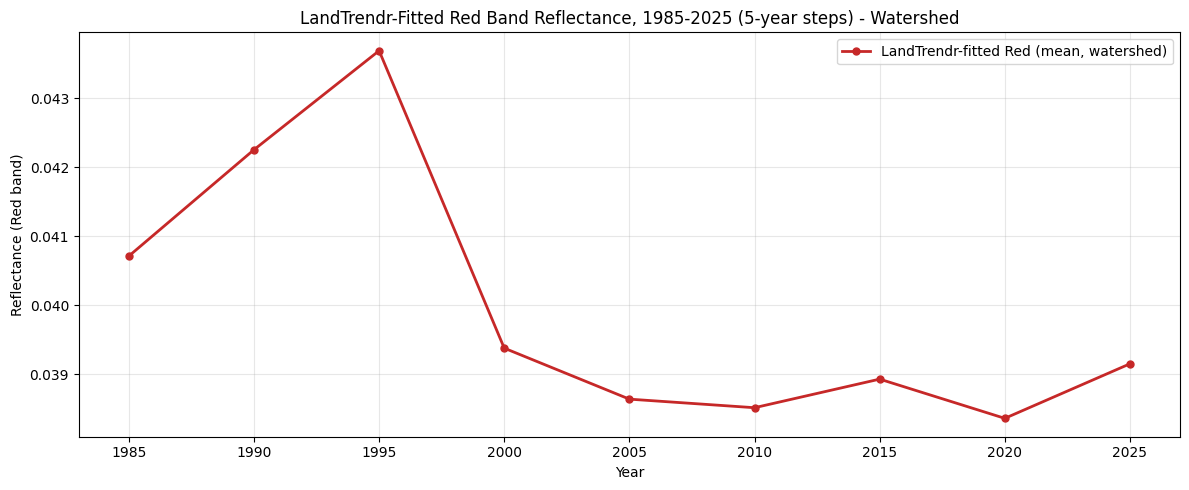

In [5]:
# -----------------------------------------------------------------------------
#  LandTrendr-fitted Red band time series -- spatial mean per year over
#  the watershed, same pattern used throughout the rest of this pipeline.
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
 
def get_mean_red(image):
    mean_dict = image.select('Red').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=watershed_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return image.set('mean_red', mean_dict.get('Red'))
 
 
annual_red_mean = LT_COLLECTION.map(get_mean_red)
 
years_red_list = annual_red_mean.aggregate_array('year').getInfo()
mean_red_fitted = annual_red_mean.aggregate_array('mean_red').getInfo()
 
print('Years:', years_red_list)
print('LandTrendr-fitted mean Red:', mean_red_fitted)
 
plt.figure(figsize=(12, 5))
plt.plot(years_red_list, mean_red_fitted, marker='o', markersize=5,
         linewidth=2, color='#C62828', label='LandTrendr-fitted Red (mean, watershed)')
plt.xlabel('Year')
plt.ylabel('Reflectance (Red band)')
plt.title('LandTrendr-Fitted Red Band Reflectance, 1985-2025 (5-year steps) - Watershed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/red_fitted_timeseries.png', dpi=150)
plt.show()

GIF URL: https://earthengine.googleapis.com/v1/projects/osmgee/videoThumbnails/912fec75d681cee680bb3d12b84fb147-5a992229318e27e0290229bd7006c066:getPixels


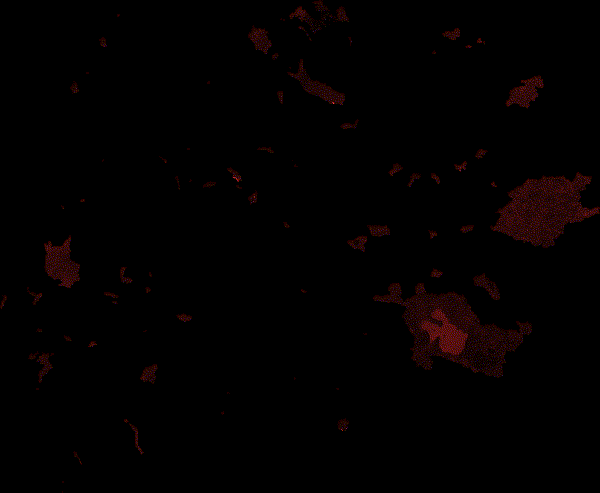

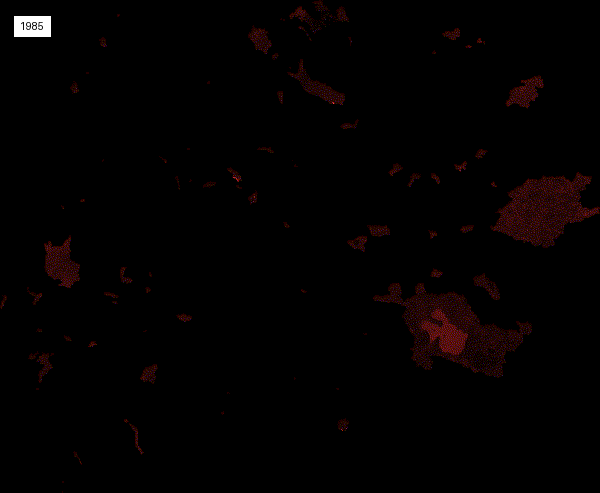

In [6]:
# -----------------------------------------------------------------------------
#  Build a time-series GIF of LandTrendr-fitted Red band
# -----------------------------------------------------------------------------
import requests
from IPython.display import Image, display
 
red_col = LT_COLLECTION.select('Red').map(
    lambda img: img.clip(watersheds)
)
 
# Red reflectance vis params -- adjust min/max if the GIF looks too
# washed out or too dark once you see it (0.0-0.3 is a reasonable
# starting range for Landsat surface reflectance, same as the
# true-colour vis used earlier in the pipeline)
vis_params_red = {
    'min':          0.0,
    'max':          0.3,
    'palette':      ['000000', '3d0d0d', '8b1a1a', 'e63232', 'ff8080', 'ffffff'],
    'region':       watershed_geom,
    'dimensions':   600,
    'framesPerSecond': 2,   # slower than the reference (3fps) -- only 9 frames total
    'crs':          'EPSG:32612'  # matches the CCDC pipeline's CRS; adjust if needed
}
 
gif_url_red = red_col.getVideoThumbURL(vis_params_red)
print('GIF URL:', gif_url_red)
 
# Download and display
gif_path_red = '/content/red_timeseries.gif'
r = requests.get(gif_url_red)
with open(gif_path_red, 'wb') as f:
    f.write(r.content)
display(Image(gif_path_red))
 
# -----------------------------------------------------------------------------
#  Add year labels burned into each frame
# -----------------------------------------------------------------------------
from PIL import Image as PILImage, ImageDraw, ImageFont
 
try:
    font = ImageFont.truetype(
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 32)
except OSError:
    font = ImageFont.load_default()
 
gif_red = PILImage.open(gif_path_red)
frames_red = []
try:
    while True:
        frame = gif_red.copy().convert('RGB')
        draw = ImageDraw.Draw(frame)
        year = found_years[gif_red.tell()]
        label = str(year)
 
        x, y = 20, 20
        bbox = draw.textbbox((x, y), label, font=font)
        pad = 6
        draw.rectangle(
            [bbox[0] - pad, bbox[1] - pad, bbox[2] + pad, bbox[3] + pad],
            fill='white'
        )
        draw.text((x, y), label, fill='black', font=font)
        frames_red.append(frame)
        gif_red.seek(gif_red.tell() + 1)
except EOFError:
    pass
 
out_gif_red = '/content/red_timeseries_labeled.gif'
frames_red[0].save(out_gif_red, save_all=True, append_images=frames_red[1:],
                    duration=500, loop=0)  # 500ms/frame -- slower, only 9 frames
 
display(Image(out_gif_red))